# Importar Librerias

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Para entrenar modelo
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
import shap



import warnings
warnings.filterwarnings('ignore')

c:\Users\jAlej\Documents\Learning\University\Tec de Monterrey\Desarrollo de aplicaciones avanzadas de ciencias computacionales\ife-student-dropout-prediction\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


##### Cargar dataset

In [193]:
df = pd.read_csv('../data/v5_dataset_pre_tec21_clusters.csv')
 
print(f"\nColumnas: {df.columns.tolist()}")
print(f"\nDistribución de clusters:\n{df['cluster_id'].value_counts().sort_index()}")


Columnas: ['generation', 'educational.model', 'age', 'max.degree.parents', 'region', 'PNA', 'admission.test', 'online.test', 'english.evaluation', 'admission.rubric', 'retention', 'FTE', 'total.scholarship.loan', 'regime', 'parents_exatec_enc', 'has_extracurriculars', 'first.generation.yes', 'first.generation.no', 'first.generation.no.information', 'estuvo.prepa_tec', 'foreign_Yes: Foreigner', 'foreign_Yes: National', 'school_EAAD-Engineering and Sciences', 'school_ECSG', 'school_EHE-EAAD', 'school_EIC', 'school_EMCS', 'school_EN', 'is_foreign', 'dropout', 'cluster_id', 'cluster_label']

Distribución de clusters:
cluster_id
0     5694
1    18392
2     2586
3    24270
4     1667
5      401
Name: count, dtype: int64


##### Obtener los clusters

In [194]:
clusters = []

for cluster_id in sorted(df['cluster_id'].unique()):
    cluster_df = df[df['cluster_id'] == cluster_id].copy()
    clusters.append(cluster_df)
    print(f"Cluster {cluster_id}: {len(cluster_df)} filas")

print(f"\nTotal de clusters creados: {len(clusters)}")

Cluster 0: 5694 filas
Cluster 1: 18392 filas
Cluster 2: 2586 filas
Cluster 3: 24270 filas
Cluster 4: 1667 filas
Cluster 5: 401 filas

Total de clusters creados: 6


Se borran columnas innecesarias.

In [195]:
FEATURES = [
    # Usadas en el clustering
    'PNA', 'is_foreign', 'estuvo.prepa_tec', 'first.generation.yes',
    'has_extracurriculars', 'parents_exatec_enc', 'total.scholarship.loan', 'FTE',
    
    # Se agregan estas
    'admission.rubric',      # information gain relevante
    'english.evaluation',    # nivel de inglés, predictor académico
    'age',                   # info gain 0.0086 en el paper
    'online.test',           # ya es binario, sin problema
    
]
# El objetivo a predecir
TARGET = 'dropout'

for i in range(len(clusters)):
    clusters[i] = clusters[i][FEATURES + [TARGET]]

In [196]:
print(clusters[0].columns.tolist())

['PNA', 'is_foreign', 'estuvo.prepa_tec', 'first.generation.yes', 'has_extracurriculars', 'parents_exatec_enc', 'total.scholarship.loan', 'FTE', 'admission.rubric', 'english.evaluation', 'age', 'online.test', 'dropout']


Funcion para entrenar regresion logistica

In [197]:
COLS_TO_SCALE = ['PNA', 'admission.rubric', 'english.evaluation', 'age']

def train_cluster_model(cluster_df, cluster_id):
    # Dropear columnas constantes (hay un solo valor unico) dinámicamente
    constant_cols = [col for col in cluster_df.columns 
                 if cluster_df[col].nunique() <= 1 and col != TARGET]
    df_clean = cluster_df.drop(columns=constant_cols)

    X = df_clean.drop(columns=[TARGET])
    y = df_clean[TARGET]

    # Escalar columnas numéricas (solo las que existen después del drop)
    cols_scale = [c for c in COLS_TO_SCALE if c in X.columns]
    scaler = StandardScaler()
    X[cols_scale] = scaler.fit_transform(X[cols_scale])

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Aplicar SMOTE solo a training para no tener un imbalanced de clases
    sm = SMOTE(random_state=42)
    X_train, y_train = sm.fit_resample(X_train, y_train)

    # Entrenar
    # el dropout es muy raro en cada cluster, por eso class_weight evita que solo prediga 'no drouput'
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    # Métricas
    THRESHOLD = 0.6 # se utiliza un menor threshold para mejorar la precision

    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= THRESHOLD).astype(int)

    print(f"\n=== Cluster {cluster_id} ({len(cluster_df)} registros) ===")
    # if constant_cols:
        # print(f"Cluster {cluster_id} — columnas constantes dropeadas: {constant_cols}")
    # print(classification_report(y_test, y_pred))
    
    explainer = shap.LinearExplainer(model, X_train)
    shap_values = explainer(X_test)
    print(f"\n--- SHAP Values Cluster {cluster_id} ---")
    shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)

    return model

Se entrenan todos los clusters y se imprime informacion


=== Cluster 0 (5694 registros) ===

--- SHAP Values Cluster 0 ---


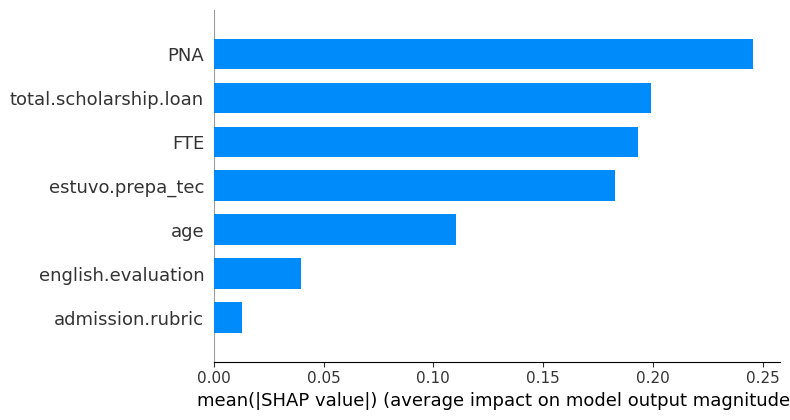


=== Cluster 1 (18392 registros) ===

--- SHAP Values Cluster 1 ---


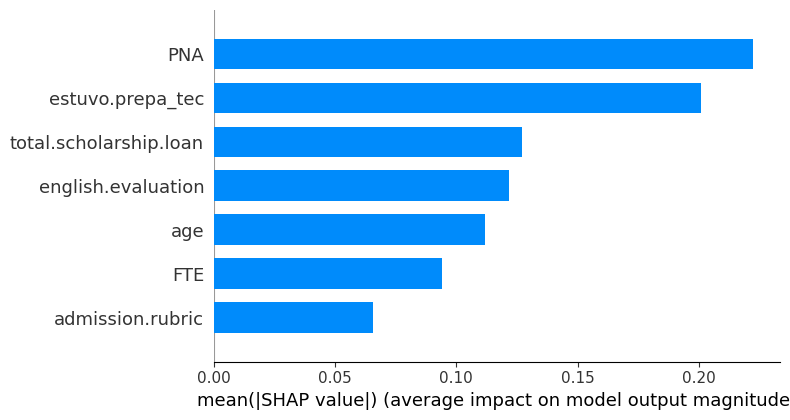


=== Cluster 2 (2586 registros) ===

--- SHAP Values Cluster 2 ---


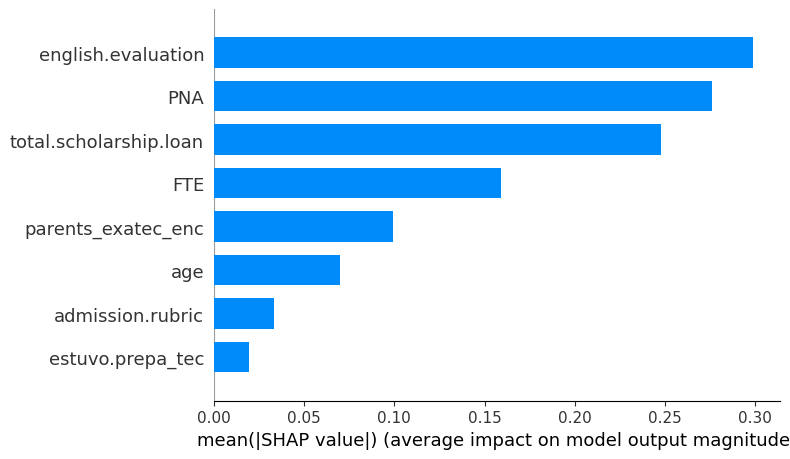


=== Cluster 3 (24270 registros) ===

--- SHAP Values Cluster 3 ---


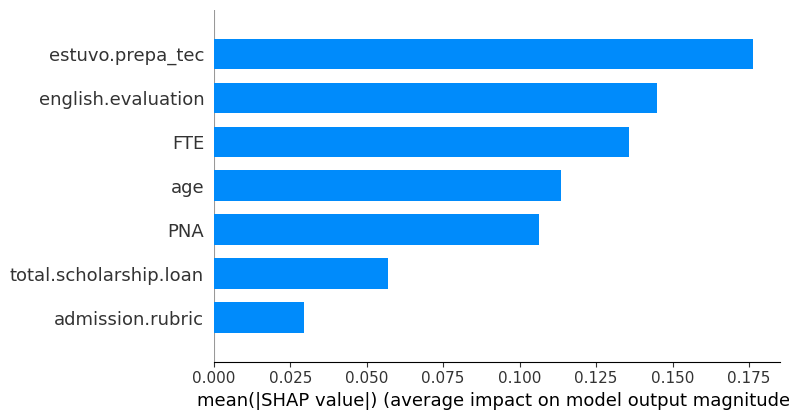


=== Cluster 4 (1667 registros) ===

--- SHAP Values Cluster 4 ---


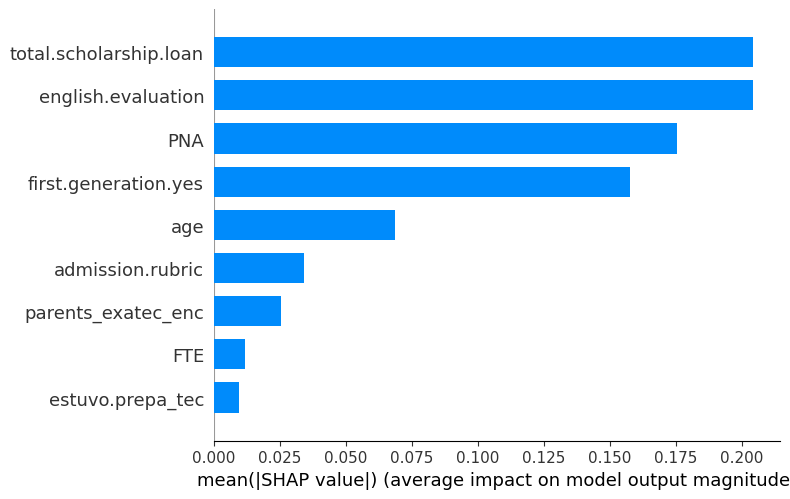


=== Cluster 5 (401 registros) ===

--- SHAP Values Cluster 5 ---


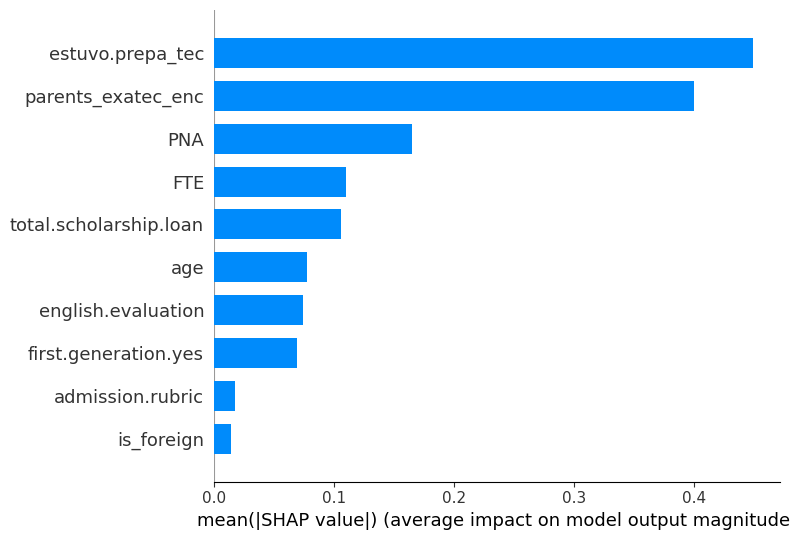

In [198]:
models = []
for cluster_id, cluster_df in enumerate(clusters):
    models.append(train_cluster_model(cluster_df, cluster_id))